In [1]:
! pip install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! chmod 600 ~/.kaggle/kaggle.json

In [4]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge


100% 285M/285M [00:01<00:00, 163MB/s]



In [5]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip


Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [6]:
! pip install kaggle wandb --quiet

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data loading

In [8]:
df = pd.read_csv("icml_face_data.csv")
df.columns = df.columns.str.strip()
print(df.shape)
print(df["Usage"].value_counts())
df.head(3)

(35887, 3)
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...


In [9]:
EMOTION_LABELS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

PIXELS_COL  = " pixels" if " pixels" in df.columns else "pixels"
EMOTION_COL = "emotion"
USAGE_COL   = "Usage"

class FERDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.labels = df[EMOTION_COL].values
        pixels = np.array(
            [np.fromstring(p, sep=" ", dtype=np.uint8) for p in df[PIXELS_COL]]
        ).reshape(-1, 48, 48)
        self.images = pixels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = self.images[idx][np.newaxis, :, :]
        img   = torch.from_numpy(img).float() / 255.0
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [10]:
MEAN, STD = 0.5071, 0.2555

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomResizedCrop(48, scale=(0.85, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Normalize(mean=[MEAN], std=[STD]),
])

val_transform = T.Compose([
    T.Normalize(mean=[MEAN], std=[STD]),
])

train_df = df[df[USAGE_COL] == "Training"].reset_index(drop=True)
val_df   = df[df[USAGE_COL] == "PublicTest"].reset_index(drop=True)

train_ds = FERDataset(train_df, transform=train_transform)
val_ds   = FERDataset(val_df,   transform=val_transform)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 28709 | Val: 3589


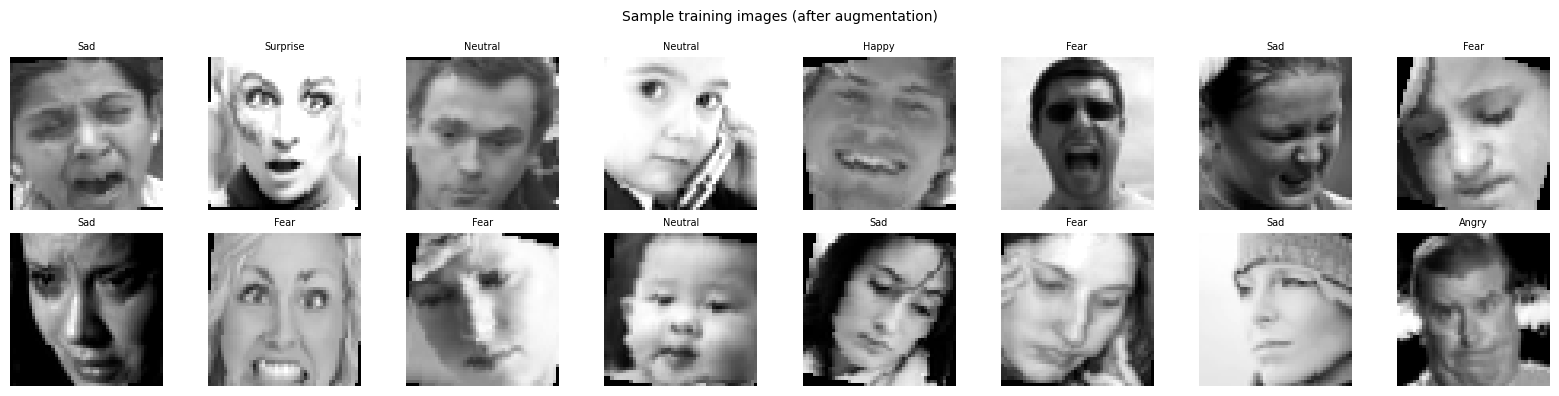

In [11]:
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, 0].numpy(), cmap="gray")
    ax.set_title(EMOTION_LABELS[lbls[i].item()], fontsize=7)
    ax.axis("off")
plt.suptitle("Sample training images (after augmentation)", fontsize=10)
plt.tight_layout()
plt.show()

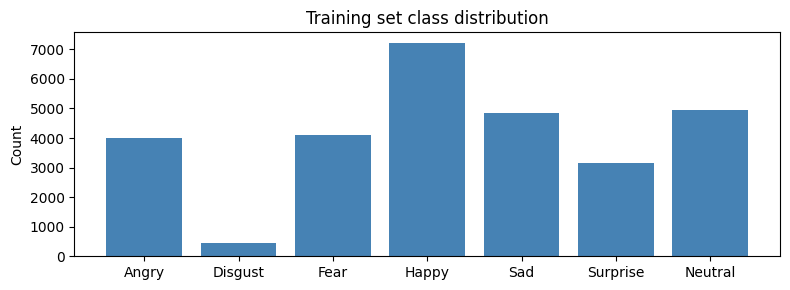

emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


In [12]:
counts = train_df[EMOTION_COL].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(EMOTION_LABELS, counts.values, color="steelblue")
ax.set_ylabel("Count")
ax.set_title("Training set class distribution")
plt.tight_layout()
plt.show()
print(counts)

## Model

In [13]:
class ConvBlock(nn.Module):
    """Double conv block: Conv-BN-ReLU → Conv-BN-ReLU → MaxPool → Dropout"""

    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class DeeperCNN(nn.Module):
    """
    4-block VGG-style CNN for FER-2013.
    Input: (B, 1, 48, 48)
    """

    def __init__(self, num_classes: int = 7,
                 conv_dropout: float = 0.25,
                 fc_dropout: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(1,   32,  conv_dropout),
            ConvBlock(32,  64,  conv_dropout),
            ConvBlock(64,  128, conv_dropout),
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


model = DeeperCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

DeeperCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.25, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, ep

## Forward & backward pass checks

In [14]:
model.eval()
with torch.no_grad():
    dummy = torch.randn(8, 1, 48, 48).to(DEVICE)
    out   = model(dummy)

print(f"Output shape : {out.shape}")
print(f"Contains NaN : {torch.isnan(out).any().item()}")
print(f"Contains Inf : {torch.isinf(out).any().item()}")
assert out.shape == (8, 7)
print("✓ Forward pass OK")

Output shape : torch.Size([8, 7])
Contains NaN : False
Contains Inf : False
✓ Forward pass OK


In [15]:
model.train()
criterion  = nn.CrossEntropyLoss()
_optimizer = optim.Adam(model.parameters(), lr=1e-3)

single_imgs, single_lbls = next(iter(train_loader))
single_imgs = single_imgs.to(DEVICE)
single_lbls = single_lbls.to(DEVICE)

print("Overfit on 1 batch for 50 steps:")
for step in range(50):
    _optimizer.zero_grad()
    loss = criterion(model(single_imgs), single_lbls)
    loss.backward()
    _optimizer.step()
    if (step + 1) % 10 == 0:
        print(f"  step {step+1:3d}  loss={loss.item():.4f}")

print("✓ Backward pass OK")

Overfit on 1 batch for 50 steps:
  step  10  loss=1.7025
  step  20  loss=1.1977
  step  30  loss=0.9815
  step  40  loss=0.5204
  step  50  loss=0.3092
✓ Backward pass OK


In [16]:
print(f"{'Parameter':<55} {'Shape':<20} {'Grad mean abs':>14}")
print("-" * 92)
dead = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if param.grad is None:
            dead.append(name)
            print(f"{name:<55} {str(tuple(param.shape)):<20} {'NO GRAD':>14}")
        else:
            print(f"{name:<55} {str(tuple(param.shape)):<20} {param.grad.abs().mean().item():>14.6f}")

if dead:
    print(f"\n⚠ Dead params: {dead}")
else:
    print("\n✓ Gradient flow OK")

model = DeeperCNN().to(DEVICE)

Parameter                                               Shape                 Grad mean abs
--------------------------------------------------------------------------------------------
features.0.block.0.weight                               (32, 1, 3, 3)              0.012910
features.0.block.0.bias                                 (32,)                      0.000000
features.0.block.1.weight                               (32,)                      0.005465
features.0.block.1.bias                                 (32,)                      0.003675
features.0.block.3.weight                               (32, 32, 3, 3)             0.005961
features.0.block.3.bias                                 (32,)                      0.000000
features.0.block.4.weight                               (32,)                      0.007856
features.0.block.4.bias                                 (32,)                      0.004766
features.1.block.0.weight                               (64, 32, 3, 3)         

## Training

In [17]:
CONFIG = dict(
    experiment   = "deeper_cnn_exp1_baseline",
    architecture = "DeeperCNN_3block_VGGstyle",
    epochs       = 50,
    batch_size   = BATCH_SIZE,
    lr           = 1e-3,
    weight_decay = 1e-4,
    conv_dropout = 0.25,
    fc_dropout   = 0.5,
    optimizer    = "Adam",
    scheduler    = "ReduceLROnPlateau",
    seed         = SEED,
)

In [18]:
wandb.login()

wandb.init(
    project = "fer2013-experiments",
    name    = CONFIG["experiment"],
    config  = CONFIG,
    tags    = ["deeper-cnn", "baseline"],
)
wandb.config.update({"total_params": sum(p.numel() for p in model.parameters())})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ntsuk22 (ntsuk22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr           = CONFIG["lr"],
    weight_decay = CONFIG["weight_decay"],
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)


def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["train_acc" ].append(tr_acc)
    history["val_loss"  ].append(vl_loss)
    history["val_acc"   ].append(vl_acc)

    wandb.log({
        "epoch"              : epoch,
        "train/loss"         : tr_loss,
        "train/acc"          : tr_acc,
        "val/loss"           : vl_loss,
        "val/acc"            : vl_acc,
        "train_val/loss_gap" : abs(tr_loss - vl_loss),
        "train_val/acc_gap"  : abs(tr_acc  - vl_acc),
        "lr"                 : optimizer.param_groups[0]["lr"],
    })

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_deeper_cnn.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{CONFIG['epochs']} "
            f"| train loss {tr_loss:.4f}  acc {tr_acc:.4f} "
            f"| val loss {vl_loss:.4f}  acc {vl_acc:.4f}"
        )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
wandb.run.summary["best_val_acc"] = best_val_acc

Epoch   1/50 | train loss 1.8194  acc 0.2414 | val loss 1.7829  acc 0.2597
Epoch   5/50 | train loss 1.5128  acc 0.3967 | val loss 1.4236  acc 0.4433
Epoch  10/50 | train loss 1.3586  acc 0.4658 | val loss 1.2805  acc 0.5227
Epoch  15/50 | train loss 1.2782  acc 0.5091 | val loss 1.2345  acc 0.5475
Epoch  20/50 | train loss 1.2058  acc 0.5409 | val loss 1.1689  acc 0.5617
Epoch  25/50 | train loss 1.1587  acc 0.5624 | val loss 1.1126  acc 0.5890
Epoch  30/50 | train loss 1.1175  acc 0.5772 | val loss 1.0689  acc 0.6010
Epoch  35/50 | train loss 1.0913  acc 0.5926 | val loss 1.0384  acc 0.6094
Epoch  40/50 | train loss 1.0791  acc 0.5929 | val loss 1.0224  acc 0.6041
Epoch  45/50 | train loss 1.0613  acc 0.6012 | val loss 1.0133  acc 0.6227
Epoch  50/50 | train loss 1.0508  acc 0.6039 | val loss 1.0109  acc 0.6219

Best validation accuracy: 0.6266


## Analysis

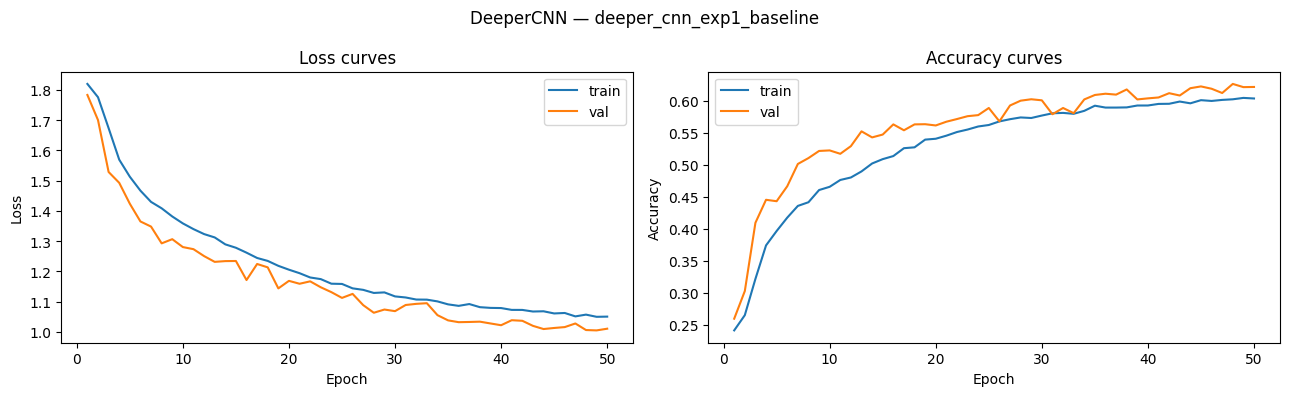

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, CONFIG["epochs"] + 1)

ax1.plot(epochs_range, history["train_loss"], label="train")
ax1.plot(epochs_range, history["val_loss"],   label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss curves"); ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="train")
ax2.plot(epochs_range, history["val_acc"],   label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy curves"); ax2.legend()

plt.suptitle(f"DeeperCNN — {CONFIG['experiment']}", fontsize=12)
plt.tight_layout()
wandb.log({"learning_curves": wandb.Image(fig)})
plt.show()

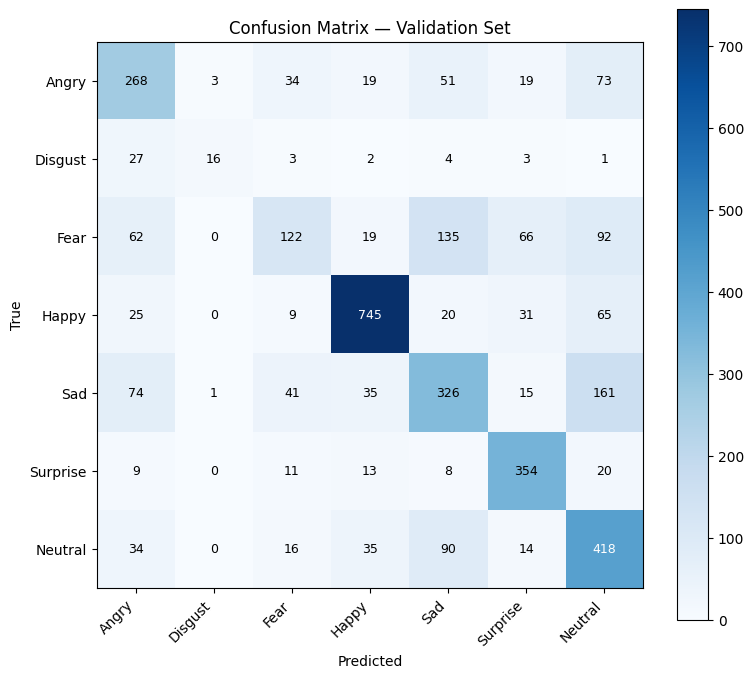


Classification report:
              precision    recall  f1-score   support

       Angry       0.54      0.57      0.55       467
     Disgust       0.80      0.29      0.42        56
        Fear       0.52      0.25      0.33       496
       Happy       0.86      0.83      0.85       895
         Sad       0.51      0.50      0.51       653
    Surprise       0.71      0.85      0.77       415
     Neutral       0.50      0.69      0.58       607

    accuracy                           0.63      3589
   macro avg       0.63      0.57      0.57      3589
weighted avg       0.63      0.63      0.62      3589



In [23]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load("best_deeper_cnn.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs  = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(7)); ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(EMOTION_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Validation Set")
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
plt.tight_layout()
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.show()

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))

In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels, all_preds,
    target_names=EMOTION_LABELS,
    output_dict=True,
)
table_data = [
    [
        emotion,
        round(report[emotion]["precision"], 3),
        round(report[emotion]["recall"], 3),
        round(report[emotion]["f1-score"], 3),
        int(report[emotion]["support"]),
    ]
    for emotion in EMOTION_LABELS
]
wandb.log({
    "per_class_metrics": wandb.Table(
        columns=["Emotion", "Precision", "Recall", "F1-score", "Support"],
        data=table_data,
    )
})

final_train_acc = history["train_acc"][-1]
final_val_acc   = history["val_acc"][-1]
gap             = final_train_acc - final_val_acc

print("=" * 55)
print(f"  Final train accuracy : {final_train_acc:.4f}")
print(f"  Final val   accuracy : {final_val_acc:.4f}")
print(f"  Train–val gap        : {gap:.4f}")
print("=" * 55)

if final_train_acc < 0.50:
    diagnosis = "UNDERFITTING — model lacks capacity."
elif gap > 0.15:
    diagnosis = "OVERFITTING — large train/val gap. Increase regularization."
elif gap < 0.05 and final_val_acc < 0.55:
    diagnosis = "UNDERFITTING with low variance — increase depth or width."
else:
    diagnosis = "Reasonable fit — continue with hyperparameter optimization."

print(f"\n  Diagnosis: {diagnosis}")

wandb.run.summary["final_train_acc"] = final_train_acc
wandb.run.summary["final_val_acc"]   = final_val_acc
wandb.run.summary["train_val_gap"]   = gap
wandb.run.summary["diagnosis"]       = diagnosis
wandb.finish()

  Final train accuracy : 0.6039
  Final val   accuracy : 0.6219
  Train–val gap        : -0.0180

  Diagnosis: Reasonable fit — continue with hyperparameter optimization.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████████
train/loss,██▇▆▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val/acc_gap,▃▅█▆▆█▇▇▅▆▅▅▆▄▅▃▃▃▃▃▁▄▄▃▁▁▃▃▃▃▂▂▂▃▂▃▃▂▃▃
train_val/loss_gap,▂▄█▄▅▅▆▄▄▄▅▃▅▁▂▂▂▁▂▂▁▃▄▃▂▁▃▃▃▃▃▃▂▂▃▃▃▂▃▂
val/acc,▁▂▄▅▅▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇██▇▇▇████████████
val/loss,█▇▆▅▅▄▄▄▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.62664
diagnosis,Reasonable fit — con...
epoch,50
